In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import mglearn

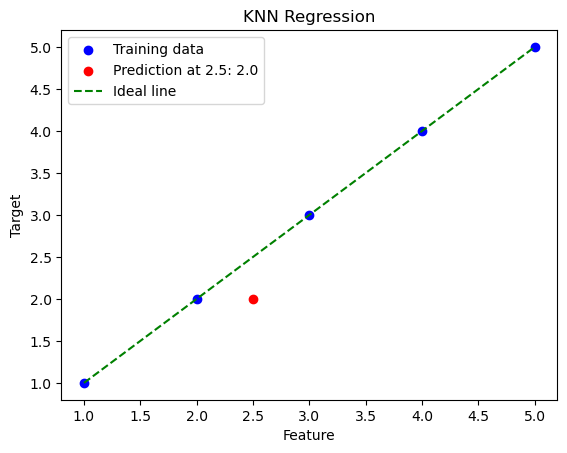

In [2]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt

# Sample data: Simple 1D feature (X) and continuous target (y)
X = np.array([[1], [2], [3], [4], [5]])  # Feature
y = np.array([1, 2, 3, 4, 5])            # Target value

# Create KNN Regression model
knn = KNeighborsRegressor(n_neighbors=3)  # Use K=3 neighbors
knn.fit(X, y)

# Make a prediction for a new point
X_new = np.array([[2.5]])
y_pred = knn.predict(X_new)

# Plot the data and prediction
plt.scatter(X, y, color='blue', label='Training data')
plt.scatter(X_new, y_pred, color='red', label=f'Prediction at 2.5: {y_pred[0]}')
plt.plot([1, 5], [1, 5], linestyle='--', color='green', label='Ideal line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.title('KNN Regression')
plt.show()

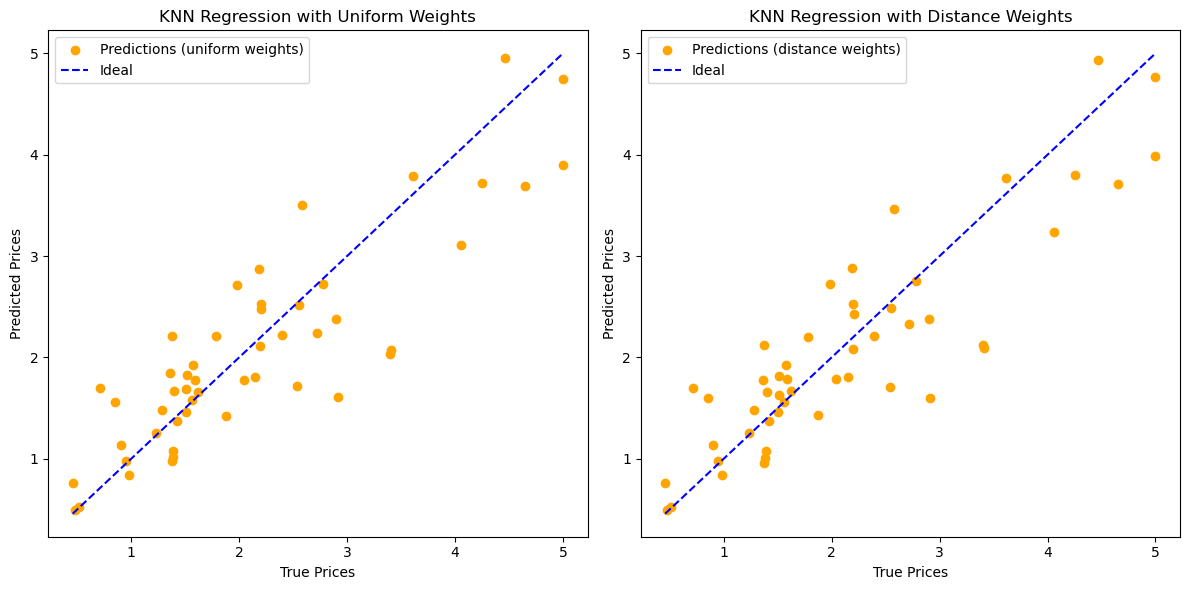

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# 1. Load the California Housing dataset
california = fetch_california_housing()
X = california.data  # Features
y = california.target  # Target (house prices)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the features to improve performance of KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. KNN Regression with k=5 and uniform weights
knn_uniform = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn_uniform.fit(X_train_scaled, y_train)

# 5. KNN Regression with k=5 and distance-based weights
knn_distance = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_distance.fit(X_train_scaled, y_train)

# 6. Make predictions
y_pred_uniform = knn_uniform.predict(X_test_scaled)
y_pred_distance = knn_distance.predict(X_test_scaled)

# 7. Plot the results for comparison (showing a subset of the data for clarity)
plt.figure(figsize=(12, 6))

# Plot Uniform weights
plt.subplot(1, 2, 1)
plt.scatter(y_test[:50], y_pred_uniform[:50], color='orange', label='Predictions (uniform weights)')
plt.plot([min(y_test[:50]), max(y_test[:50])], [min(y_test[:50]), max(y_test[:50])], color='blue', linestyle='--', label='Ideal')
plt.xlabel('True Prices')
plt.ylabel('Predicted Prices')
plt.title('KNN Regression with Uniform Weights')
plt.legend()

# Plot Distance weights
plt.subplot(1, 2, 2)
plt.scatter(y_test[:50], y_pred_distance[:50], color='orange', label='Predictions (distance weights)')
plt.plot([min(y_test[:50]), max(y_test[:50])], [min(y_test[:50]), max(y_test[:50])], color='blue', linestyle='--', label='Ideal')
plt.xlabel('True Prices')
plt.ylabel('Predicted Prices')
plt.title('KNN Regression with Distance Weights')
plt.legend()

plt.tight_layout()
plt.show()